# 【解答編】2026年9月15日 2026機械学習PJ 第3回 画像処理，自然言語処理 演習ノートブック

本ノートブックでは，演習を通して以下の内容を理解することを目的とする:

1. CNNによる画像分類モデルの構築と学習を実際に行う．
2. Vision Transformerで使われるパッチの考え方を画像で確認する．
3. Transformerによる文章分類を実際に試す．
4. CLIPを使い，画像と文章の対応度を比較する．
5. 画像処理，自然言語処理，マルチモーダルモデルにおける処理を，同じモデル構築の流れとして整理する．

作成者: 坪井 一馬 (本資料は生成AIを使用して作成した部分がありますが，最終的な責任は坪井に帰属します)

## 0. 共通準備

このノートブックの実行にあたって，必ず最初に実行しておくこと．途中で「ランタイムが切断」されるなどあれば，再度実行すること．

### 0.1. モジュールのインポートなど

必要となるPythonの機能を使えるようにする．

⭐️**重要**⭐️ **最初にGoogle Colabの設定において「T4 GPU」を使用する設定にしてください．画面右上にある「▼」から選択できます．**

In [18]:
# Python標準ライブラリ
import copy
import importlib.util
import random
import subprocess
import sys

# 数値計算・可視化
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# PyTorch
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import (
    DataLoader,
    Subset,
    random_split,
)
from torchvision import datasets, transforms

# Transformers
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, CLIPModel, CLIPProcessor

In [19]:
# 実行ごとの差を小さくするため，乱数を固定する
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# T4 GPUが利用できる場合はGPU，利用できない場合はCPUを使用する
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("使用するデバイス:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

使用するデバイス: cuda
GPU: Tesla T4


### 0.2. Fashion-MNISTの読み込み

In [20]:
# Fashion-MNISTでは，画像をPyTorchのTensorへ変換するだけにする
transform = transforms.ToTensor()

# 学習用として用意されている60,000枚を読み込む
full_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

# テスト用として用意されている10,000枚を読み込む
test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

# 学習用60,000枚を，訓練50,000枚と評価10,000枚へ分割する
split_generator = torch.Generator().manual_seed(
    RANDOM_STATE
)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [50000, 10000],
    generator=split_generator,
)

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

print("訓練データ:", len(train_dataset))
print("評価データ:", len(val_dataset))
print("テストデータ:", len(test_dataset))

訓練データ: 50000
評価データ: 10000
テストデータ: 10000


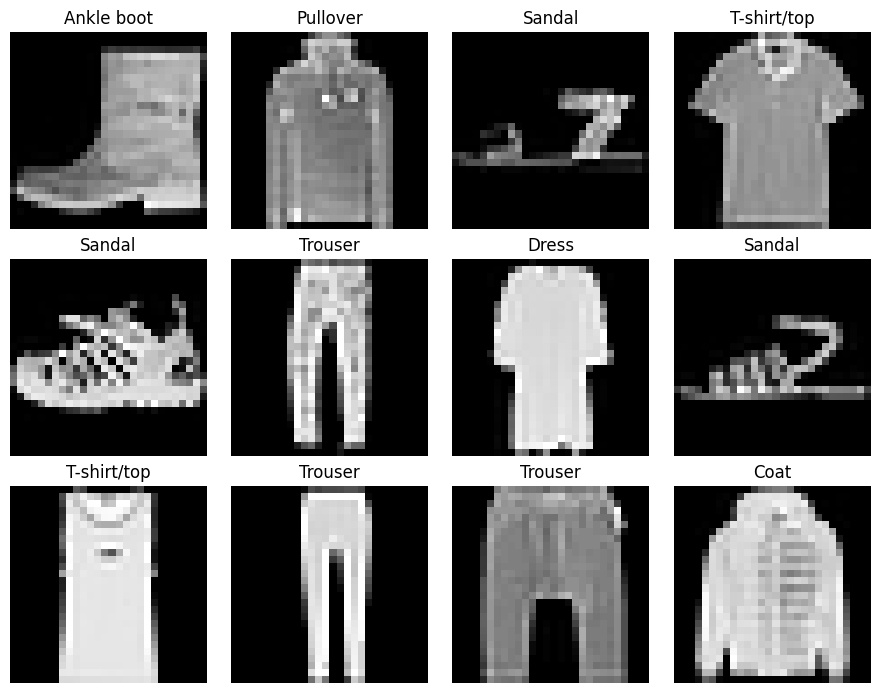

In [21]:
# Fashion-MNISTの画像を12枚表示する
fig, axes = plt.subplots(
    3,
    4,
    figsize=(9, 7),
)

for index, ax in enumerate(axes.flat):
    image, label = train_dataset[index]

    ax.imshow(
        image.squeeze(),
        cmap="gray",
    )

    ax.set_title(
        class_names[label]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

## 演習1. CNNによるFashion-MNIST分類

次のパーツA〜Gを正しい順番へ並び替え，CNNの構築，学習，テストまでを完成させよ．考える順番は次の通りです．

1. データを準備する．  
2. CNNを定義する．  
3. モデル，損失関数，Optimizerを準備する．  
4. 学習と評価に必要な関数を準備する．  
5. 複数Epoch学習する．  
6. テストデータで最終評価する．

### パーツ

セル単位で配置すること．

#### A

```python
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("訓練データのミニバッチ数:", len(train_loader))
```

#### B

```python
class FashionCNN(nn.Module):
    def __init__(
        self,
        base_filters=16,
    ):
        super().__init__()

        # 画像から特徴を取り出す部分
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=base_filters,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=base_filters,
                out_channels=base_filters * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # 取り出した特徴から10クラスを分類する部分
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                base_filters * 2 * 7 * 7,
                64,
            ),
            nn.ReLU(),

            nn.Linear(
                64,
                10,
            ),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x
```

#### C

```python
def train_one_epoch(
    model,
    data_loader,
    loss_function,
    optimizer,
    device,
):
    # 学習モードへ切り替える
    model.train()

    total_loss = 0.0
    total_count = 0

    predictions_all = []
    labels_all = []

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 1. 前回の勾配をリセットする
        optimizer.zero_grad()

        # 2. 現在のモデルで予測する
        logits = model(images)

        # 3. 予測と正解のずれを計算する
        loss = loss_function(
            logits,
            labels,
        )

        # 4. 損失を小さくする修正方向を計算する
        loss.backward()

        # 5. 実際にパラメータを更新する
        optimizer.step()

        predictions = logits.argmax(
            dim=1
        )

        total_loss += (
            loss.item()
            * images.size(0)
        )

        total_count += labels.size(0)

        predictions_all.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
        )

        labels_all.extend(
            labels
            .detach()
            .cpu()
            .numpy()
        )

    return {
        "loss": total_loss / total_count,
        "accuracy": accuracy_score(
            labels_all,
            predictions_all,
        ),
    }
```

#### D

```python
BASE_FILTERS = 16
LEARNING_RATE = 0.001

model = FashionCNN(
    base_filters=BASE_FILTERS,
).to(device)

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

print(model)
```

#### E

```python
def evaluate_model(
    model,
    data_loader,
    loss_function,
    device,
):
    # 評価モードへ切り替える
    model.eval()

    total_loss = 0.0
    total_count = 0

    predictions_all = []
    labels_all = []

    # 評価時は勾配を計算しない
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = loss_function(
                logits,
                labels,
            )

            predictions = logits.argmax(
                dim=1
            )

            total_loss += (
                loss.item()
                * images.size(0)
            )

            total_count += labels.size(0)

            predictions_all.extend(
                predictions
                .cpu()
                .numpy()
            )

            labels_all.extend(
                labels
                .cpu()
                .numpy()
            )

    return {
        "loss": total_loss / total_count,
        "accuracy": accuracy_score(
            labels_all,
            predictions_all,
        ),
        "predictions": np.array(
            predictions_all
        ),
        "labels": np.array(
            labels_all
        ),
    }
```

#### F

```python
# 評価データで最も良かった時点のモデルへ戻す
model.load_state_dict(
    best_model_state
)

test_result = evaluate_model(
    model,
    test_loader,
    loss_function,
    device,
)

print(
    f"Test Loss: "
    f"{test_result['loss']:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_result['accuracy']:.3f}"
)
```

#### G

```python
MAX_EPOCHS = 4

train_loss_history = []
train_accuracy_history = []

val_loss_history = []
val_accuracy_history = []

best_val_loss = float("inf")
best_epoch = None
best_model_state = None

for epoch in range(MAX_EPOCHS):
    train_result = train_one_epoch(
        model,
        train_loader,
        loss_function,
        optimizer,
        device,
    )

    val_result = evaluate_model(
        model,
        val_loader,
        loss_function,
        device,
    )

    train_loss_history.append(
        train_result["loss"]
    )

    train_accuracy_history.append(
        train_result["accuracy"]
    )

    val_loss_history.append(
        val_result["loss"]
    )

    val_accuracy_history.append(
        val_result["accuracy"]
    )

    # 評価Lossが最も小さい時点のモデルを保存する
    if val_result["loss"] < best_val_loss:
        best_val_loss = val_result["loss"]
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

    print(
        f"Epoch {epoch + 1:2d} | "
        f"Train Loss {train_result['loss']:.4f} | "
        f"Val Loss {val_result['loss']:.4f} | "
        f"Train Acc {train_result['accuracy']:.3f} | "
        f"Val Acc {val_result['accuracy']:.3f}"
    )

print()
print("評価Lossが最小だったEpoch:", best_epoch)
```

### 回答

#### (1) データの準備

In [22]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("訓練データのミニバッチ数:", len(train_loader))

訓練データのミニバッチ数: 391


#### (2) モデルの準備

In [23]:
class FashionCNN(nn.Module):
    def __init__(
        self,
        base_filters=16,
    ):
        super().__init__()

        # 画像から特徴を取り出す部分
        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=base_filters,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=base_filters,
                out_channels=base_filters * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # 取り出した特徴から10クラスを分類する部分
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                base_filters * 2 * 7 * 7,
                64,
            ),
            nn.ReLU(),

            nn.Linear(
                64,
                10,
            ),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

In [24]:
BASE_FILTERS = 16
LEARNING_RATE = 0.001

model = FashionCNN(
    base_filters=BASE_FILTERS,
).to(device)

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

print(model)

FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)


#### (3) 学習

In [25]:
def train_one_epoch(
    model,
    data_loader,
    loss_function,
    optimizer,
    device,
):
    # 学習モードへ切り替える
    model.train()

    total_loss = 0.0
    total_count = 0

    predictions_all = []
    labels_all = []

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        # 1. 前回の勾配をリセットする
        optimizer.zero_grad()

        # 2. 現在のモデルで予測する
        logits = model(images)

        # 3. 予測と正解のずれを計算する
        loss = loss_function(
            logits,
            labels,
        )

        # 4. 損失を小さくする修正方向を計算する
        loss.backward()

        # 5. 実際にパラメータを更新する
        optimizer.step()

        predictions = logits.argmax(
            dim=1
        )

        total_loss += (
            loss.item()
            * images.size(0)
        )

        total_count += labels.size(0)

        predictions_all.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
        )

        labels_all.extend(
            labels
            .detach()
            .cpu()
            .numpy()
        )

    return {
        "loss": total_loss / total_count,
        "accuracy": accuracy_score(
            labels_all,
            predictions_all,
        ),
    }

In [26]:
def evaluate_model(
    model,
    data_loader,
    loss_function,
    device,
):
    # 評価モードへ切り替える
    model.eval()

    total_loss = 0.0
    total_count = 0

    predictions_all = []
    labels_all = []

    # 評価時は勾配を計算しない
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = loss_function(
                logits,
                labels,
            )

            predictions = logits.argmax(
                dim=1
            )

            total_loss += (
                loss.item()
                * images.size(0)
            )

            total_count += labels.size(0)

            predictions_all.extend(
                predictions
                .cpu()
                .numpy()
            )

            labels_all.extend(
                labels
                .cpu()
                .numpy()
            )

    return {
        "loss": total_loss / total_count,
        "accuracy": accuracy_score(
            labels_all,
            predictions_all,
        ),
        "predictions": np.array(
            predictions_all
        ),
        "labels": np.array(
            labels_all
        ),
    }

In [27]:
MAX_EPOCHS = 4

train_loss_history = []
train_accuracy_history = []

val_loss_history = []
val_accuracy_history = []

best_val_loss = float("inf")
best_epoch = None
best_model_state = None

for epoch in range(MAX_EPOCHS):
    train_result = train_one_epoch(
        model,
        train_loader,
        loss_function,
        optimizer,
        device,
    )

    val_result = evaluate_model(
        model,
        val_loader,
        loss_function,
        device,
    )

    train_loss_history.append(
        train_result["loss"]
    )

    train_accuracy_history.append(
        train_result["accuracy"]
    )

    val_loss_history.append(
        val_result["loss"]
    )

    val_accuracy_history.append(
        val_result["accuracy"]
    )

    # 評価Lossが最も小さい時点のモデルを保存する
    if val_result["loss"] < best_val_loss:
        best_val_loss = val_result["loss"]
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

    print(
        f"Epoch {epoch + 1:2d} | "
        f"Train Loss {train_result['loss']:.4f} | "
        f"Val Loss {val_result['loss']:.4f} | "
        f"Train Acc {train_result['accuracy']:.3f} | "
        f"Val Acc {val_result['accuracy']:.3f}"
    )

print()
print("評価Lossが最小だったEpoch:", best_epoch)

Epoch  1 | Train Loss 0.6537 | Val Loss 0.4711 | Train Acc 0.768 | Val Acc 0.829
Epoch  2 | Train Loss 0.3986 | Val Loss 0.3787 | Train Acc 0.857 | Val Acc 0.863
Epoch  3 | Train Loss 0.3481 | Val Loss 0.3277 | Train Acc 0.874 | Val Acc 0.881
Epoch  4 | Train Loss 0.3186 | Val Loss 0.3197 | Train Acc 0.887 | Val Acc 0.883

評価Lossが最小だったEpoch: 4


#### (4) テスト

In [28]:
# 評価データで最も良かった時点のモデルへ戻す
model.load_state_dict(
    best_model_state
)

test_result = evaluate_model(
    model,
    test_loader,
    loss_function,
    device,
)

print(
    f"Test Loss: "
    f"{test_result['loss']:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_result['accuracy']:.3f}"
)

Test Loss: 0.3330
Test Accuracy: 0.878


## 演習2. Vision Transformerのパッチを作る

Vision Transformerでは，画像を小さなパッチへ分割し，各パッチをトークンのように扱う．

28×28画素のFashion-MNIST画像を，7×7画素のパッチへ分割するコードを完成させよ．

パッチ数: 16


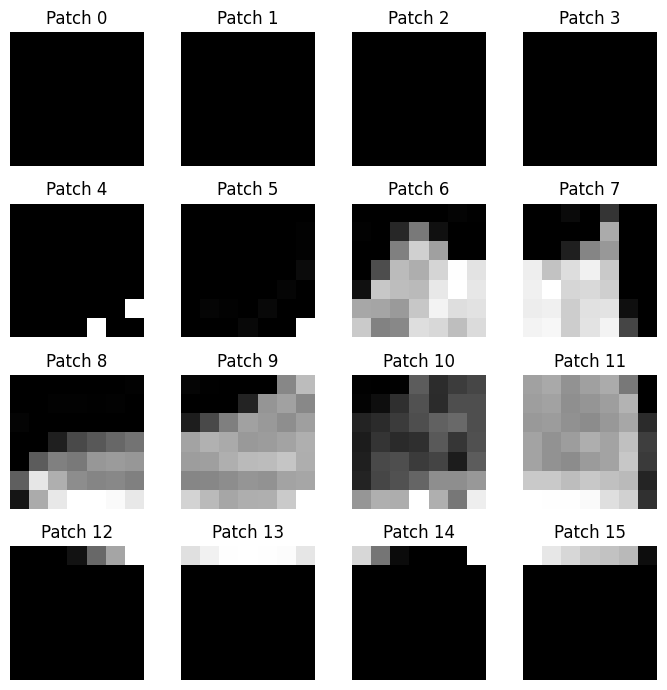

In [29]:
image, label = test_dataset[0]
PATCH_SIZE = 7
image_2d = image.squeeze()
patches = []

for row in range(0, 28, PATCH_SIZE):
    for col in range(0, 28, PATCH_SIZE):
        patch = image_2d[
            row:row + PATCH_SIZE,
            col:col + PATCH_SIZE,
        ]
        patches.append(patch)

print("パッチ数:", len(patches))

fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for index, ax in enumerate(axes.flat):
    ax.imshow(patches[index], cmap="gray")
    ax.set_title(f"Patch {index}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 演習3. Transformerによる文章の感情分類

事前学習済みDistilBERTを利用した文章の感情分類を行う．まず，以下のセルをそのまま実行せよ．

In [30]:
# まずはこのセルを実行すること．このセルの内容は原則として変更しないこと．
# transformersが入っていない環境では，最初の1回だけインストールする
if importlib.util.find_spec("transformers") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "transformers",
    ])

from transformers import pipeline

sentiment_analyzer = pipeline(
    task="sentiment-analysis",
    model=(
        "distilbert/"
        "distilbert-base-uncased-finetuned-sst-2-english"
    ),
    device=(0 if torch.cuda.is_available() else -1),
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

上のセルを実行した後に，以下の `MY_TEXT` の内容を変更し，以下のような文章がどのように分類されるかを確認せよ．特に，以下のような特徴のある文章を試行せよ．

1. 明らかにPositiveな文章．
2. 明らかにNegativeな文章．
3. `not` を含む文章．
4. `not bad` など，単語だけでは判断しにくい文章．

In [31]:
# 自分で変更する
MY_TEXT = "This class was much more interesting than I expected."

result = sentiment_analyzer(MY_TEXT)[0]
tokens = sentiment_analyzer.tokenizer.tokenize(MY_TEXT)

print("入力文:")
print(MY_TEXT)
print("\トークン:")
print(tokens)
print("\n分類結果:")
print(result)

入力文:
This class was much more interesting than I expected.
\トークン:
['this', 'class', 'was', 'much', 'more', 'interesting', 'than', 'i', 'expected', '.']

分類結果:
{'label': 'POSITIVE', 'score': 0.9992085099220276}


## 演習4. CLIPで画像と文章を比較する

CLIPへFashion-MNISTの画像1枚と複数の文章を入力し，どの文章が画像に最も対応しているかを比較する．まず，以下のセルをそのまま実行せよ．

In [32]:
# まずはこのセルを実行すること．このセルの内容は原則として変更しないこと．
from transformers import CLIPModel, CLIPProcessor

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(
    CLIP_MODEL_NAME
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    CLIP_MODEL_NAME
)

clip_model.eval()

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, eleme

次の2つを試行し，その結果を見て，CLIPが通常の10クラス分類器とどのように違うか説明せよ．

1. `SAMPLE_INDEX` を変更し，別のFashion-MNIST画像を入力する．
2. `text_candidates` の文章を1つ以上，自分なりの表現へ変更する．

In [33]:
SAMPLE_INDEX = 0
sample_image, true_label = test_dataset[SAMPLE_INDEX]

pil_image = transforms.ToPILImage()(
    sample_image
).convert("RGB")

text_candidates = [
    "a photo of a t-shirt",
    "a photo of trousers",
    "a photo of a pullover",
    "a photo of a dress",
    "a photo of a coat",
    "a photo of sandals",
    "a photo of a shirt",
    "a photo of sneakers",
    "a photo of a bag",
    "a photo of ankle boots",
]

clip_inputs = clip_processor(
    text=text_candidates,
    images=pil_image,
    return_tensors="pt",
    padding=True,
)

clip_inputs = {
    key: value.to(device)
    for key, value in clip_inputs.items()
}

with torch.no_grad():
    clip_outputs = clip_model(**clip_inputs)
    similarities = (
        clip_outputs.logits_per_image
        .softmax(dim=1)
        .squeeze(0)
        .cpu()
        .numpy()
    )

result_df = pd.DataFrame({
    "text": text_candidates,
    "similarity": similarities,
}).sort_values("similarity", ascending=False)

display(result_df)

,text,similarity
7,a photo of sneakers,0.872524
9,a photo of ankle boots,0.101080
5,a photo of sandals,0.015809
2,a photo of a pullover,0.003845
1,a photo of trousers,0.003214
8,a photo of a bag,0.002074
4,a photo of a coat,0.000682
3,a photo of a dress,0.000482
0,a photo of a t-shirt,0.000157
6,a photo of a shirt,0.000134


**【模範解答例】**

通常の10クラス分類器では，学習時にあらかじめ決められた10個の出力クラスから1つを選ぶ．

一方CLIPでは，画像と文章をそれぞれベクトルへ変換し，画像と各文章の対応度を比較する．そのため，候補となる文章を変えると比較対象自体を変更できる．

ただし，Fashion-MNISTは小さなグレースケール画像であり，CLIPが主に学習した自然画像とは条件が異なるため，結果が常に正しいとは限らない．